# SWB: Per-category evaluator vs baseline scatter plots (all evaluators)

Claude Sonnet 4.6 is the baseline. Each evaluator model is compared against it per category.
Rows where the baseline has all-zero scores (content filter hits) are excluded from all comparisons.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams["figure.dpi"] = 120

## Load baseline and all evaluator results

In [2]:
results_dir = Path("../dataset/results")
baseline_path = results_dir / "claude_sonnet_4.6.csv"

SCORE_COLS = [
    "Grammar, Spelling, and Punctuation Quality",
    "Clarity and Understandability",
    "Logical Connection Between Events and Ideas",
    "Scene Construction and Purpose",
    "Internal Consistency",
    "Character Consistency",
    "Character Motivation and Actions",
    "Sentence Pattern Variety",
    "Avoidance of Clichés and Overused Phrases",
    "Natural Dialogue",
    "Avoidance of Predictable Narrative Tropes",
    "Character Depth and Dimensionality",
    "Realistic Character Interactions",
    "Ability to Hold Reader Interest",
    "Satisfying Plot Resolution",
]

def pretty_name(stem: str) -> str:
    s = stem.replace("_swb_result", "").replace("_it", "").replace("_result", "")
    s = s.replace("-Instruct-2507", "").replace("-Instruct", "")
    s = s.replace("nvidia-", "").replace("-bf16", "")
    return s

baseline_df = pd.read_csv(baseline_path)

# Filter out all-zero rows (content filter hits)
score_col_names = [f"{c}_score" for c in SCORE_COLS]
all_zero_mask = (baseline_df[score_col_names] == 0).all(axis=1)
print(f"Removing {all_zero_mask.sum()} all-zero rows from baseline")
baseline_df = baseline_df[~all_zero_mask].reset_index(drop=True)

evaluators = {}
for p in sorted(results_dir.glob("*.csv")):
    if p == baseline_path:
        continue
    evaluators[pretty_name(p.stem)] = pd.read_csv(p)

print(f"Baseline rows: {len(baseline_df)}")
for name, df in evaluators.items():
    print(f"  {name}: {len(df)} rows")

Removing 3 all-zero rows from baseline
Baseline rows: 3477
  gemma-4-E2B: 3480 rows
  gemma-4-E4B: 3480 rows
  llama-3.2-3B: 3480 rows
  nemotron3-nano-4b: 3480 rows
  qwen3-4B: 3480 rows
  qwen3.5-4B: 3480 rows


## Build long-format table of (baseline, evaluator) score pairs

In [3]:
keys = ["index", "model"]

pair_frames = []
for name, df in evaluators.items():
    m = df.merge(baseline_df, on=keys, suffixes=("_ev", "_ref"), validate="one_to_one")
    for cat in SCORE_COLS:
        col = f"{cat}_score"
        pair_frames.append(pd.DataFrame({
            "evaluator": name,
            "category": cat,
            "baseline": m[f"{col}_ref"].to_numpy(),
            "score": m[f"{col}_ev"].to_numpy(),
        }))

pairs = pd.concat(pair_frames, ignore_index=True)
pairs.head()

,evaluator,category,baseline,score
0,gemma-4-E2B,"Grammar, Spelling, and Punctuation Quality",4,4
1,gemma-4-E2B,"Grammar, Spelling, and Punctuation Quality",4,4
2,gemma-4-E2B,"Grammar, Spelling, and Punctuation Quality",4,4
3,gemma-4-E2B,"Grammar, Spelling, and Punctuation Quality",4,4
4,gemma-4-E2B,"Grammar, Spelling, and Punctuation Quality",4,4


## Scatter plot grid

Each subplot is one rubric category. Each evaluator has its own color. The dashed grey line is $y=x$ (perfect agreement with baseline). A small jitter is applied so overlapping integer scores remain visible.

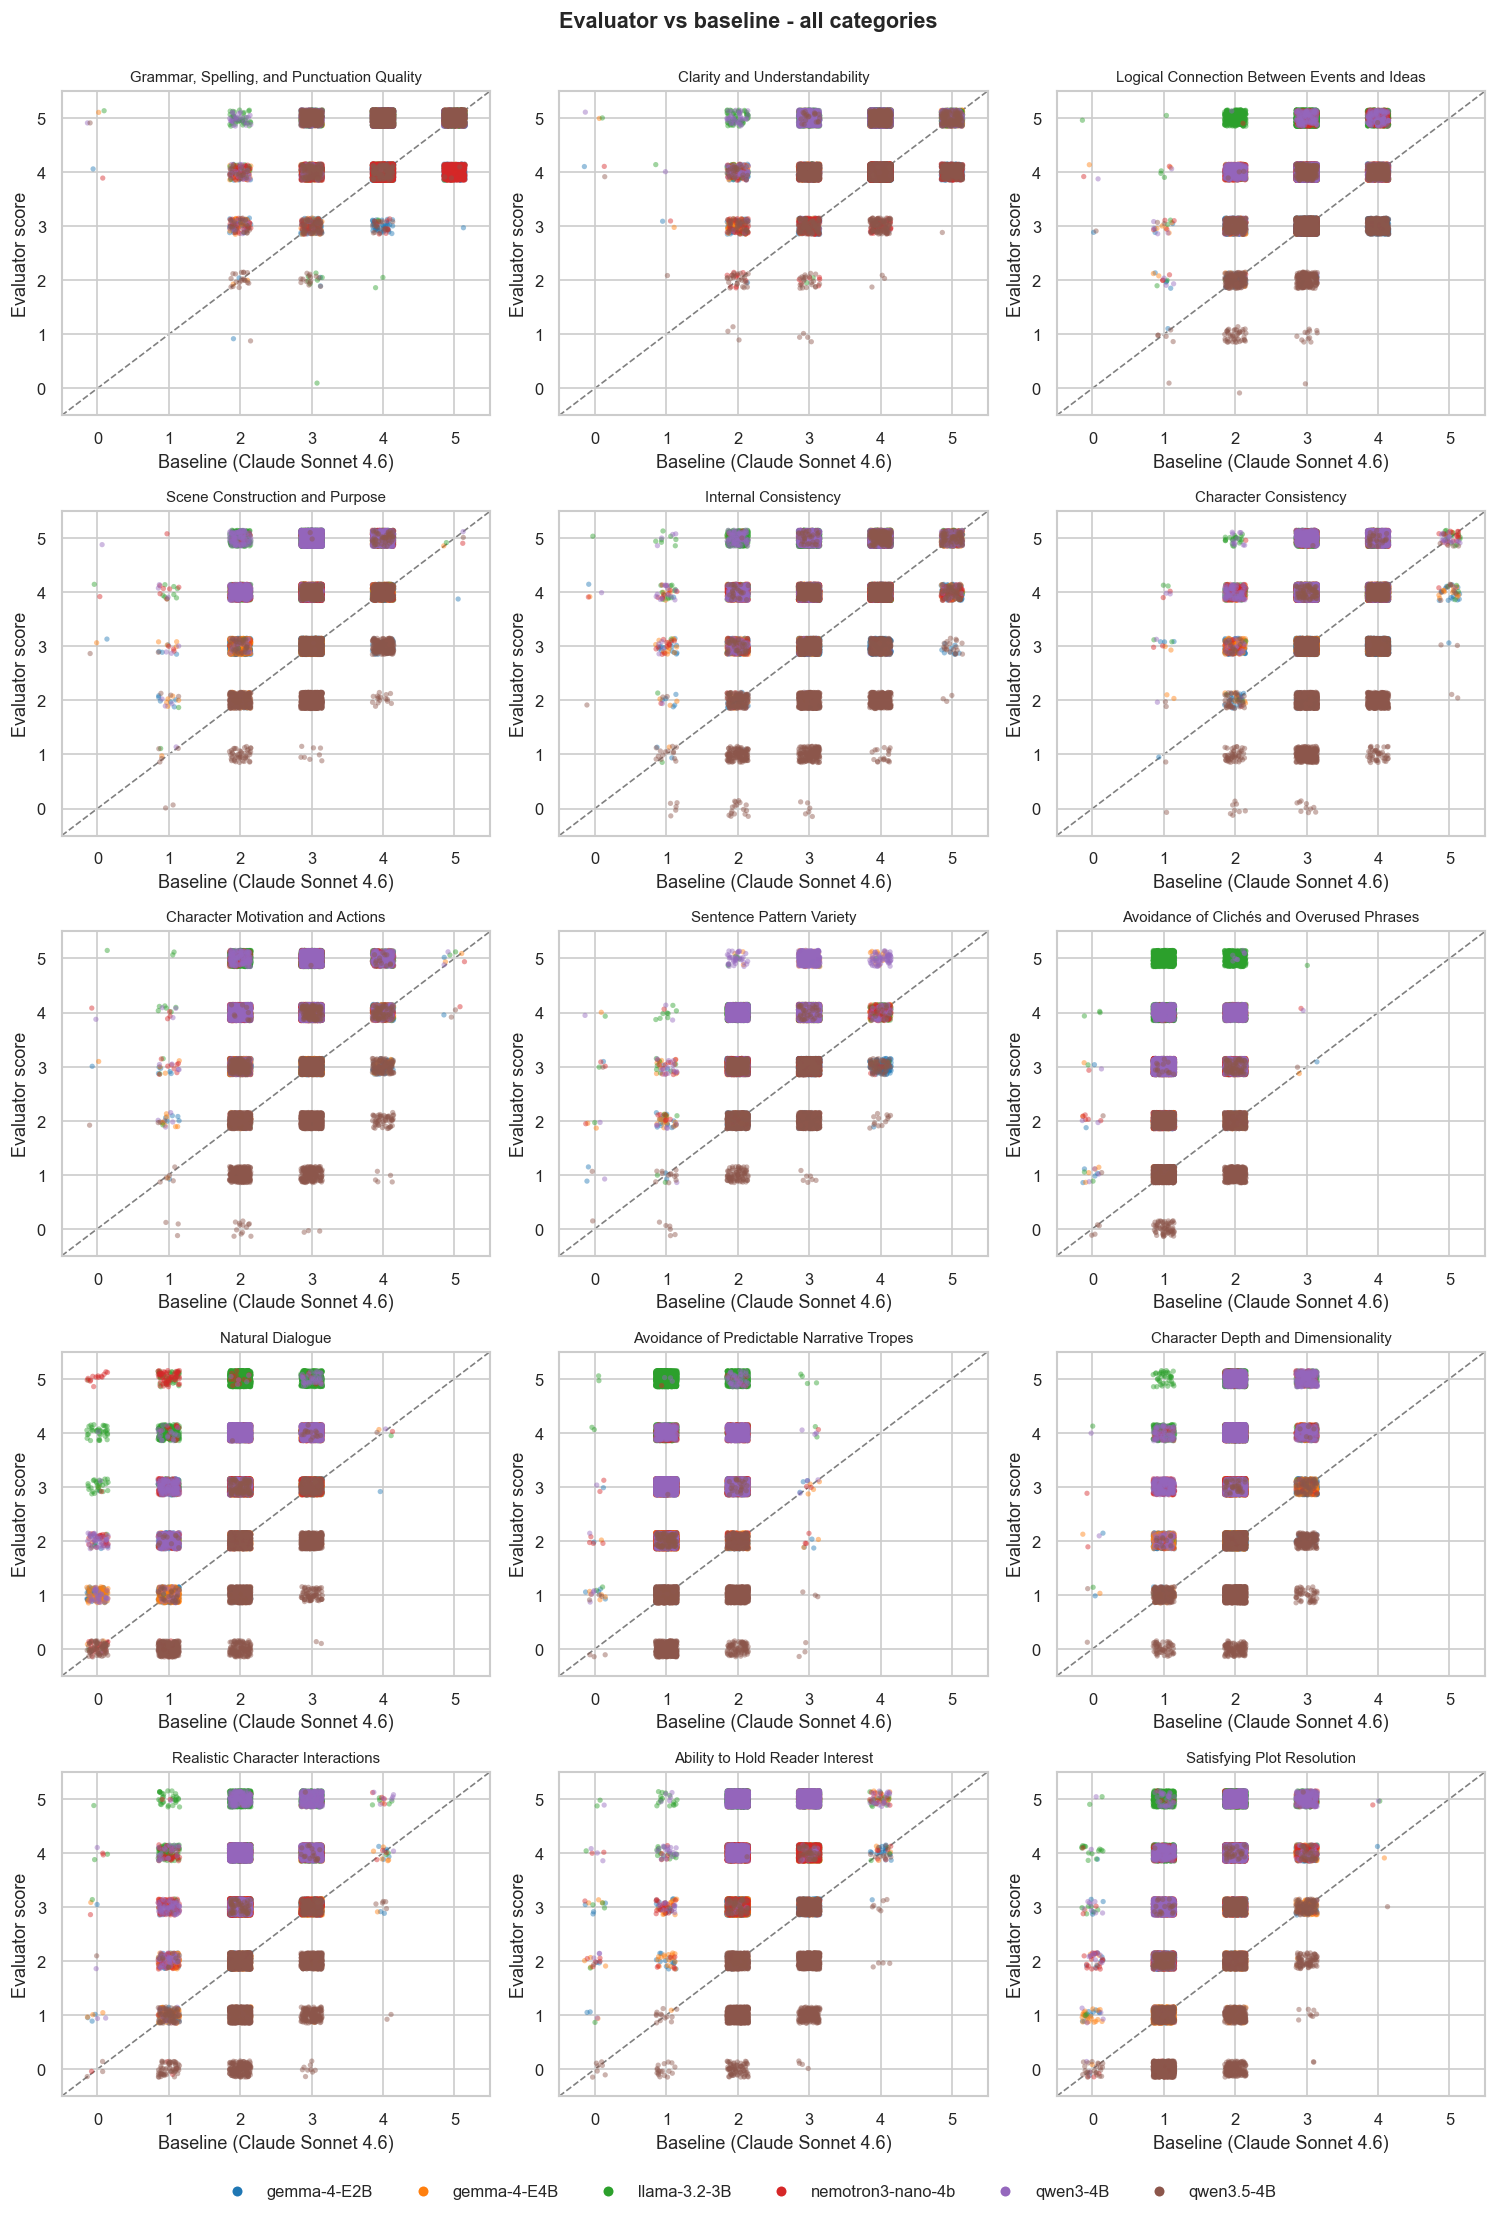

In [4]:
evaluator_names = sorted(evaluators.keys())
palette = dict(zip(evaluator_names, sns.color_palette("tab10", n_colors=len(evaluator_names))))

def scatter_grid(categories, title, ncols=3, jitter=0.15):
    n = len(categories)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows), squeeze=False)
    rng = np.random.default_rng(0)

    for ax, cat in zip(axes.ravel(), categories):
        sub = pairs[pairs["category"] == cat]
        for ev in evaluator_names:
            s = sub[sub["evaluator"] == ev]
            if s.empty:
                continue
            x = s["baseline"].to_numpy() + rng.uniform(-jitter, jitter, len(s))
            y = s["score"].to_numpy() + rng.uniform(-jitter, jitter, len(s))
            ax.scatter(x, y, s=10, alpha=0.45, color=palette[ev], label=ev, edgecolors="none")

        lo = float(min(sub["baseline"].min(), sub["score"].min()))
        hi = float(max(sub["baseline"].max(), sub["score"].max()))
        pad = 0.5
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", color="grey", lw=1, zorder=0)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_title(cat, fontsize=9)
        ax.set_xlabel("Baseline (Claude Sonnet 4.6)")
        ax.set_ylabel("Evaluator score")

    for ax in axes.ravel()[n:]:
        ax.set_visible(False)

    handles = [plt.Line2D([0], [0], marker="o", color="w",
                          markerfacecolor=palette[ev], markersize=7, label=ev)
               for ev in evaluator_names]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(evaluator_names), 6),
               bbox_to_anchor=(0.5, -0.02), frameon=False)
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.0)
    fig.tight_layout()
    plt.show()

scatter_grid(SCORE_COLS, "Evaluator vs baseline - all categories")

## Per-category agreement summary (Pearson correlation heatmap)

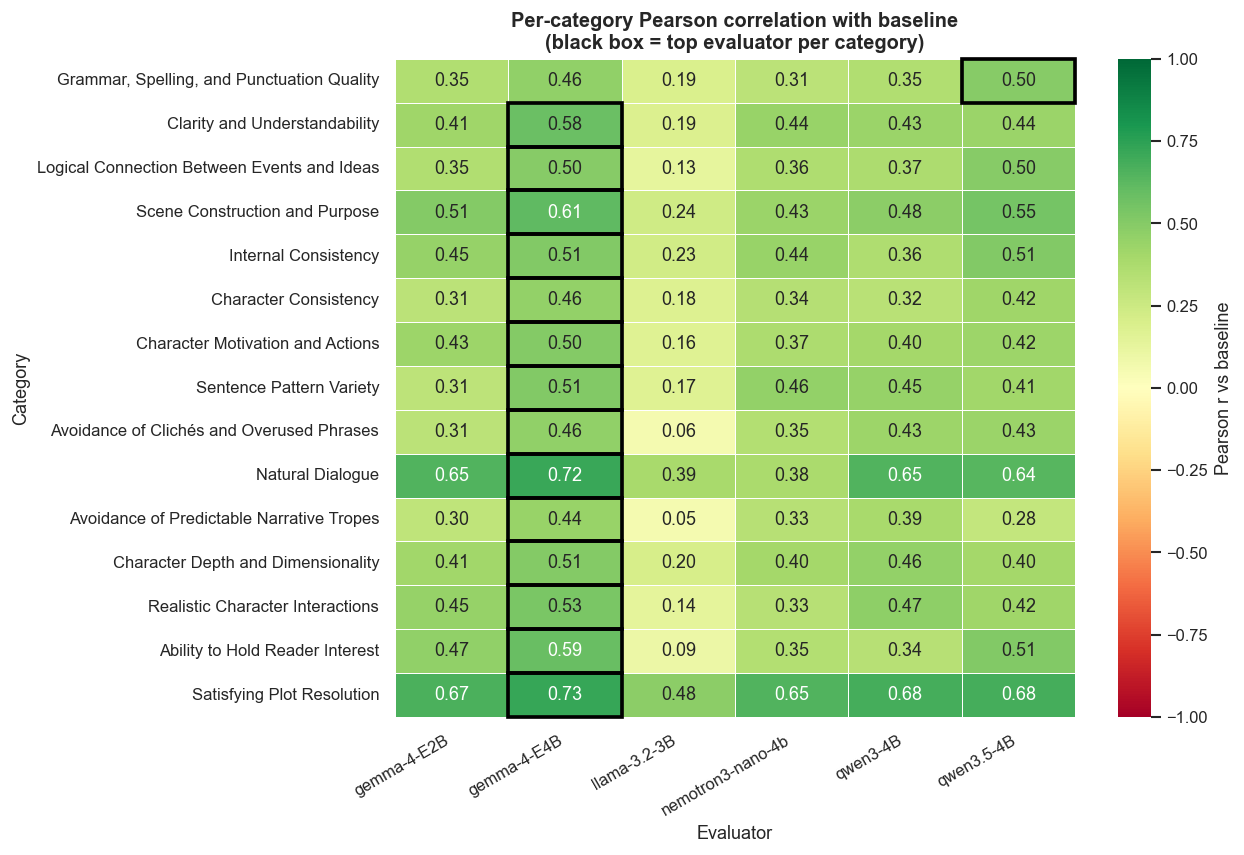

,evaluator,category,n,pearson_r,bias,mae
0,gemma-4-E2B,Ability to Hold Reader Interest,3477,0.468509,0.913719,0.914294
1,gemma-4-E4B,Ability to Hold Reader Interest,3477,0.588656,1.265746,1.265746
2,llama-3.2-3B,Ability to Hold Reader Interest,3477,0.094482,2.498131,2.498131
3,nemotron3-nano-4b,Ability to Hold Reader Interest,3477,0.349844,1.614898,1.615473
4,qwen3-4B,Ability to Hold Reader Interest,3477,0.335833,2.476273,2.476273
...,...,...,...,...,...,...
85,gemma-4-E4B,Sentence Pattern Variety,3477,0.514607,0.872304,0.876905
86,llama-3.2-3B,Sentence Pattern Variety,3477,0.167340,1.293932,1.295657
87,nemotron3-nano-4b,Sentence Pattern Variety,3477,0.456768,0.740869,0.746621
88,qwen3-4B,Sentence Pattern Variety,3477,0.446298,1.362381,1.362381


In [5]:
def compute_agreement(pairs_df):
    rows = []
    for (ev, cat), g in pairs_df.groupby(["evaluator", "category"]):
        x = g["baseline"].to_numpy()
        y = g["score"].to_numpy()
        mask = ~(np.isnan(x) | np.isnan(y))
        x, y = x[mask], y[mask]
        if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
            r = np.nan
        else:
            r = float(np.corrcoef(x, y)[0, 1])
        diff = y - x
        rows.append({
            "evaluator": ev,
            "category": cat,
            "n": int(len(x)),
            "pearson_r": r,
            "bias": float(diff.mean()) if len(diff) else np.nan,
            "mae": float(np.abs(diff).mean()) if len(diff) else np.nan,
        })
    return pd.DataFrame(rows)


def plot_agreement_heatmap(pairs_df, title="Per-category Pearson correlation with baseline",
                           highlight_winner=True):
    agree_df = compute_agreement(pairs_df)
    pivot = (
        agree_df.pivot_table(index="category", columns="evaluator", values="pearson_r")
        .reindex(index=SCORE_COLS, columns=evaluator_names)
    )

    plt.figure(figsize=(1.1 * len(evaluator_names) + 4, 0.35 * len(pivot) + 2))
    ax = sns.heatmap(pivot, cmap="RdYlGn", vmin=-1, vmax=1, center=0,
                     annot=True, fmt=".2f", linewidths=0.4, linecolor="white",
                     cbar_kws={"label": "Pearson r vs baseline"})

    if highlight_winner:
        max_cols = pivot.idxmax(axis=1)
        for row_idx, cat in enumerate(pivot.index):
            ev = max_cols.loc[cat]
            if pd.isna(ev):
                continue
            col_idx = pivot.columns.get_loc(ev)
            ax.add_patch(mpatches.Rectangle((col_idx, row_idx), 1, 1,
                                            fill=False, edgecolor="black",
                                            lw=2.2, clip_on=False))
        title = f"{title}\n(black box = top evaluator per category)"

    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel("Evaluator")
    plt.ylabel("Category")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    return ax


agreement = compute_agreement(pairs)
plot_agreement_heatmap(pairs)
plt.show()

agreement.sort_values(["category", "evaluator"]).reset_index(drop=True)

## Stability check via square-root subsampling

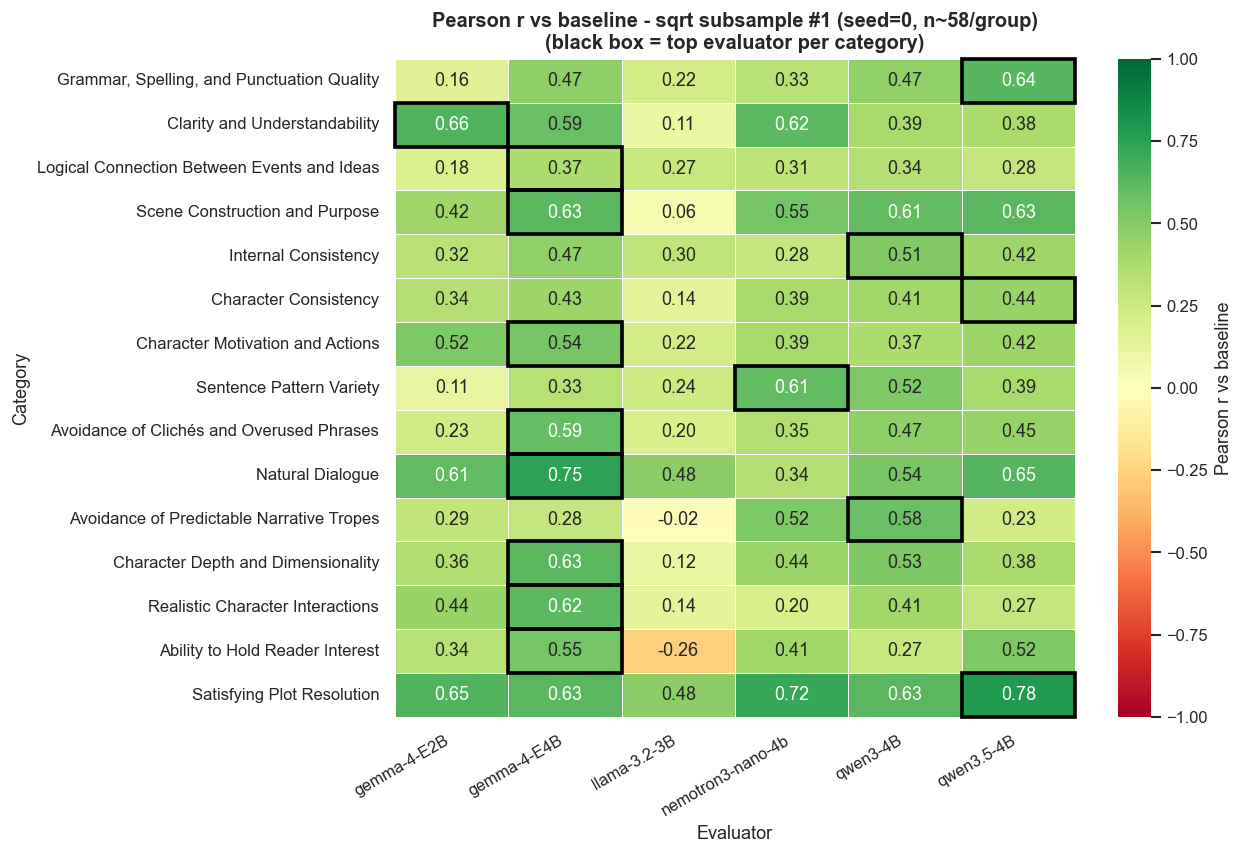

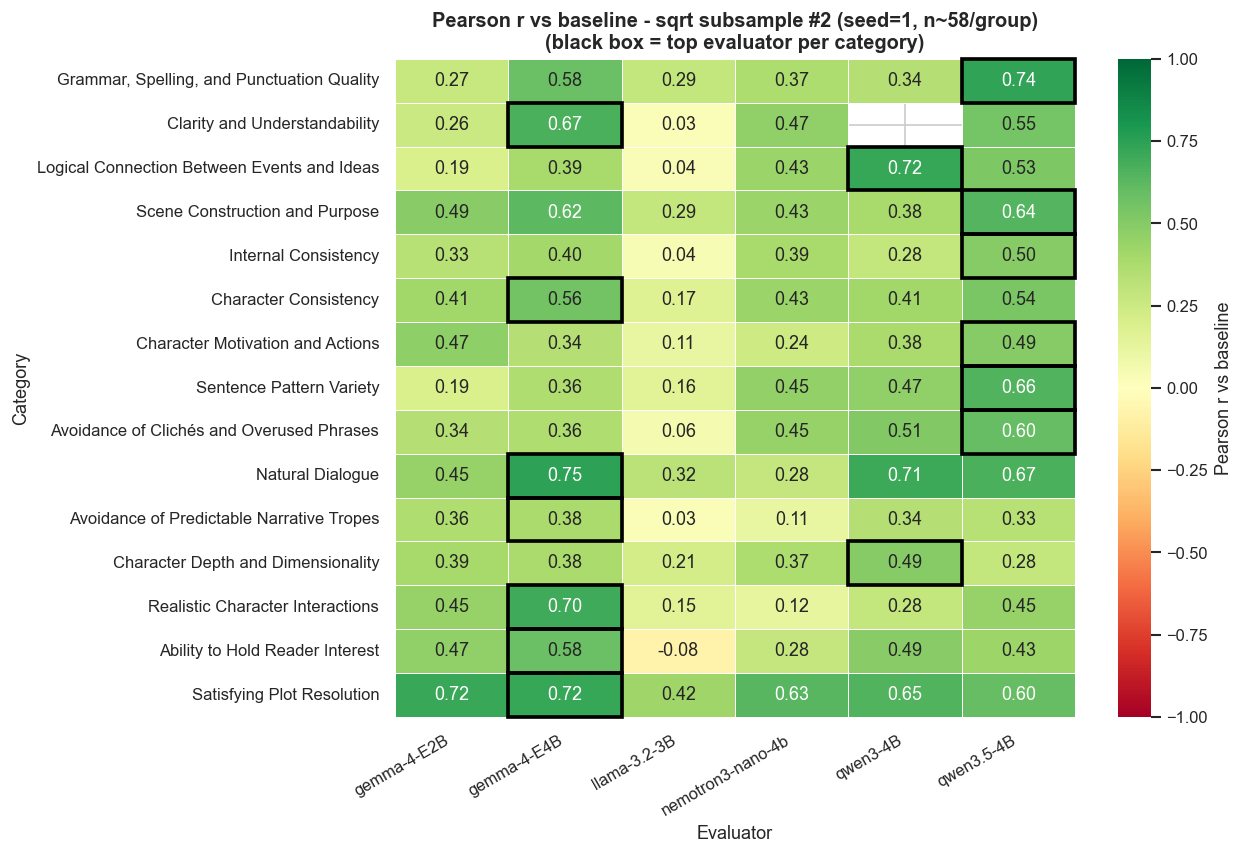

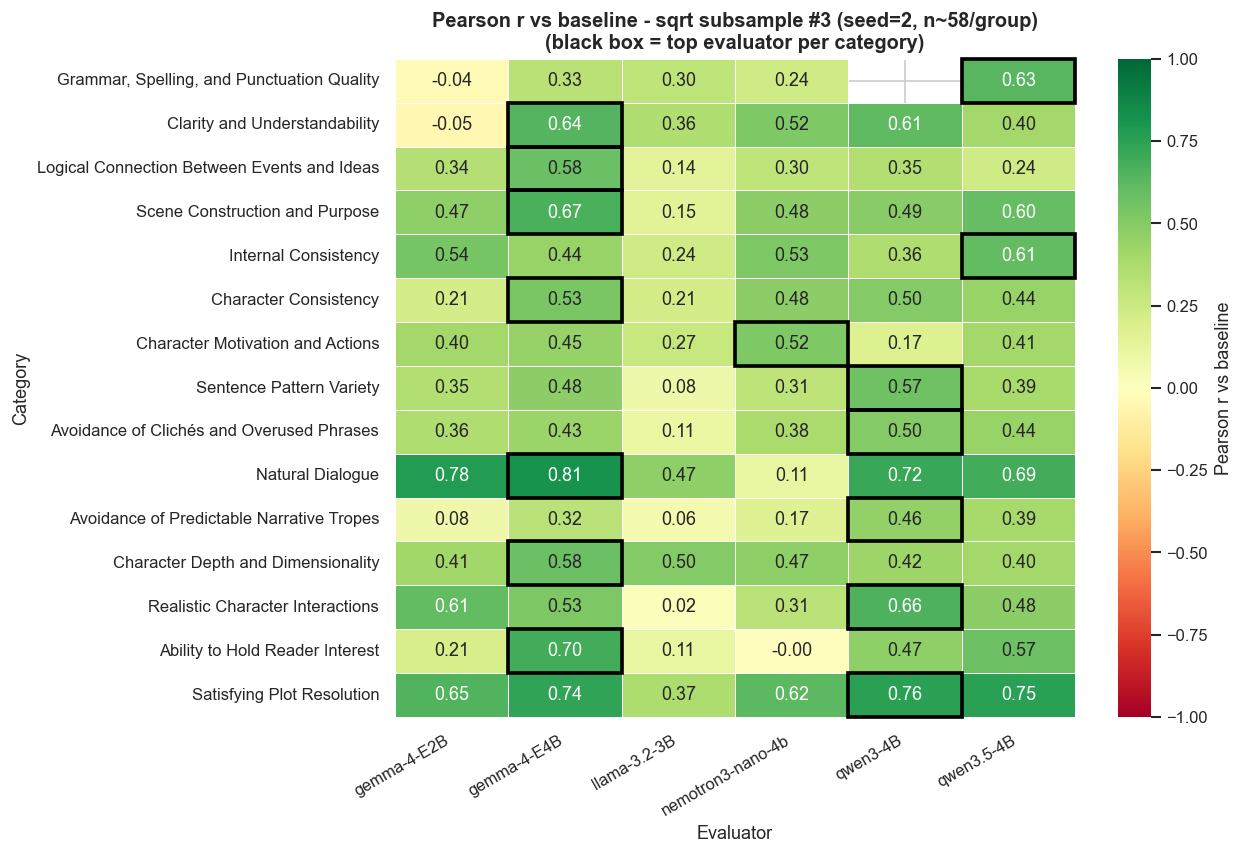

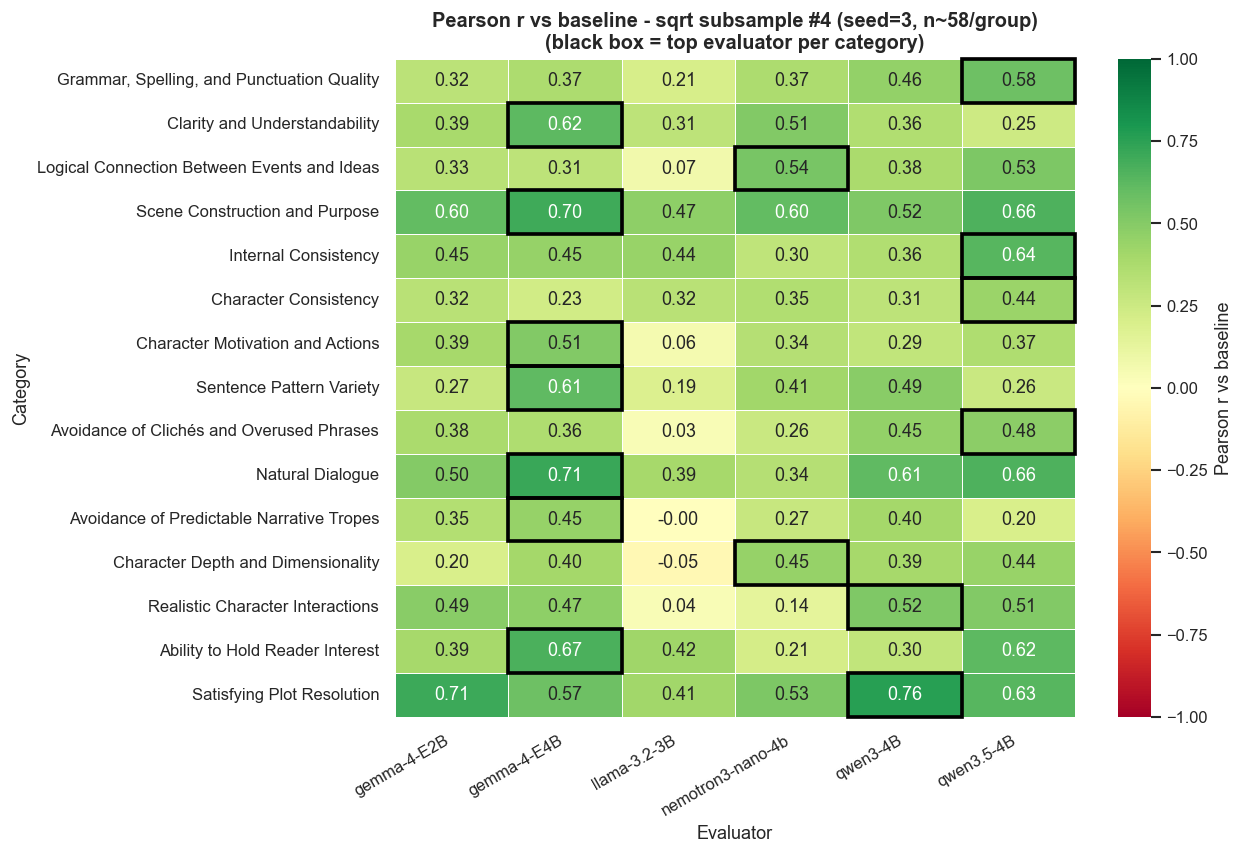

In [6]:
def sqrt_subsample(pairs_df, seed):
    rng = np.random.default_rng(seed)
    parts = []
    for _, g in pairs_df.groupby(["evaluator", "category"], sort=False):
        k = max(2, int(np.sqrt(len(g))))
        idx = rng.choice(len(g), size=min(k, len(g)), replace=False)
        parts.append(g.iloc[idx])
    return pd.concat(parts, ignore_index=True)


N_FIGURES = 4
for i in range(N_FIGURES):
    sample = sqrt_subsample(pairs, seed=i)
    n_per_group = int(np.sqrt(len(pairs) // (len(evaluator_names) * len(SCORE_COLS))))
    plot_agreement_heatmap(
        sample,
        title=(f"Pearson r vs baseline - sqrt subsample #{i + 1} "
               f"(seed={i}, n~{n_per_group}/group)"),
    )
    plt.tight_layout()
    plt.show()

## Mean-rank winner across subsamples

Overall mean rank (lower = better):
                   mean_rank  std_rank    n
evaluator                                  
gemma-4-E4B         1.998667  1.210214  750
qwen3.5-4B          2.825333  1.423679  750
qwen3-4B            3.297151  1.463284  737
gemma-4-E2B         3.507363  1.388728  747
nemotron3-nano-4b   3.752674  1.430798  748
llama-3.2-3B        5.554217  0.876070  747


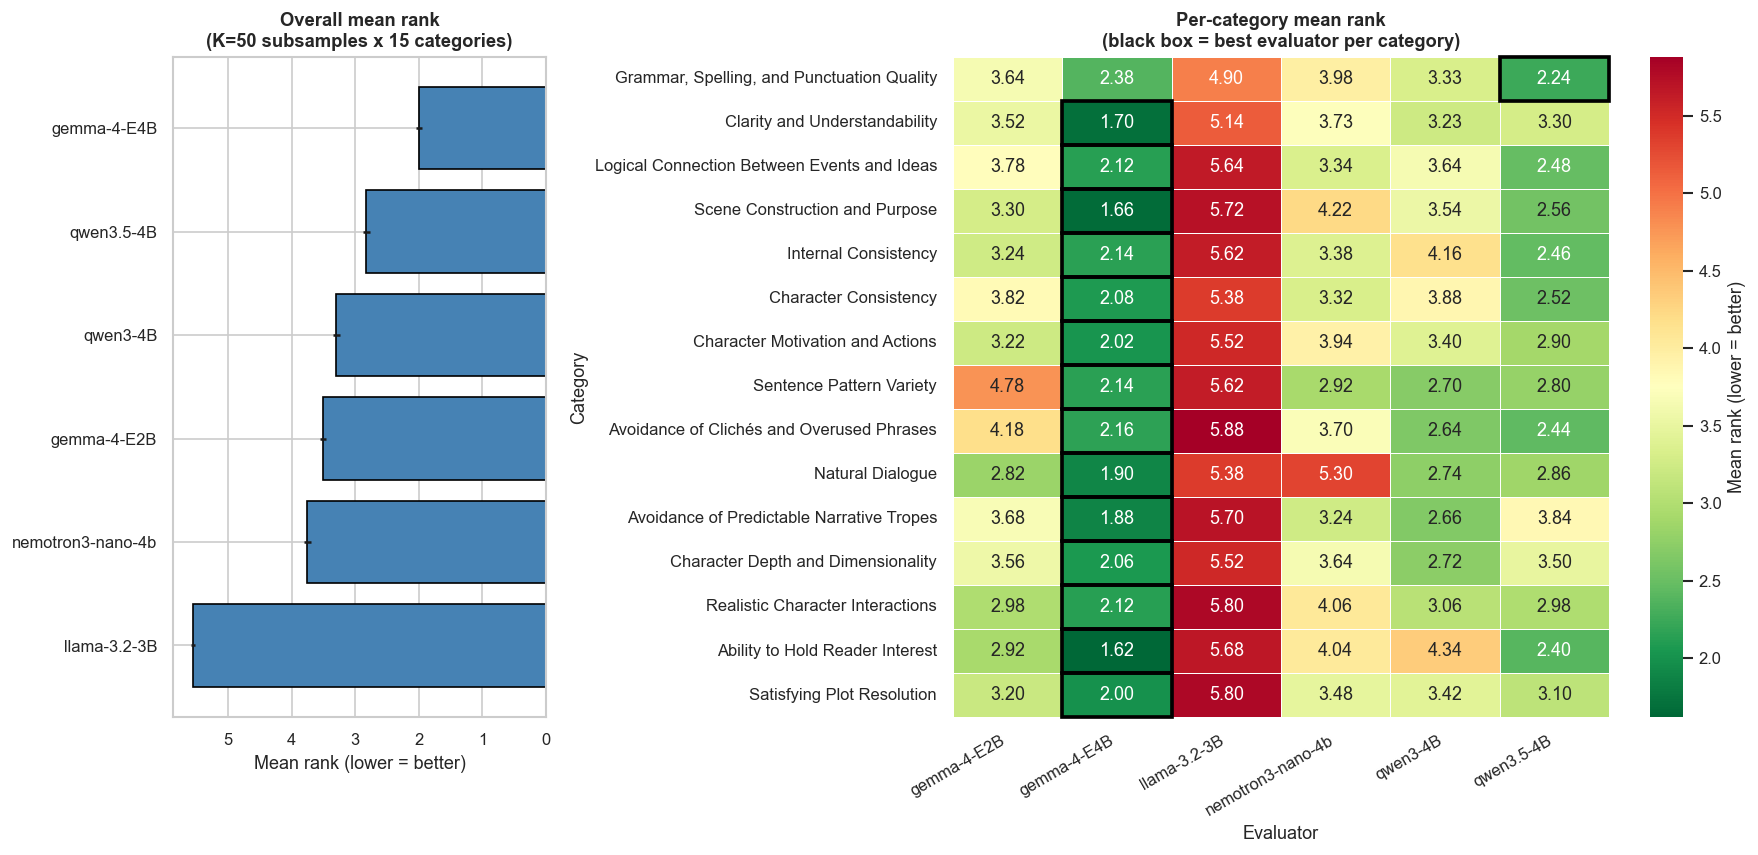

,mean_rank,std_rank,n
evaluator,,,
gemma-4-E4B,1.998667,1.210214,750
qwen3.5-4B,2.825333,1.423679,750
qwen3-4B,3.297151,1.463284,737
gemma-4-E2B,3.507363,1.388728,747
nemotron3-nano-4b,3.752674,1.430798,748
llama-3.2-3B,5.554217,0.876070,747


In [7]:
K_SUBSAMPLES = 50

rank_frames = []
for seed in range(K_SUBSAMPLES):
    sample = sqrt_subsample(pairs, seed=seed)
    agree = compute_agreement(sample)
    pivot = agree.pivot_table(index="category", columns="evaluator", values="pearson_r")
    ranks = pivot.rank(axis=1, method="average", ascending=False)
    ranks = ranks.assign(seed=seed).reset_index().melt(
        id_vars=["category", "seed"], var_name="evaluator", value_name="rank"
    )
    rank_frames.append(ranks)

ranks_long = pd.concat(rank_frames, ignore_index=True)

overall = (
    ranks_long.groupby("evaluator")["rank"]
    .agg(["mean", "std", "count"])
    .reindex(evaluator_names)
    .rename(columns={"mean": "mean_rank", "std": "std_rank", "count": "n"})
)
print("Overall mean rank (lower = better):")
print(overall.sort_values("mean_rank"))

per_cat = (
    ranks_long.groupby(["category", "evaluator"])["rank"].mean()
    .unstack("evaluator")
    .reindex(index=SCORE_COLS, columns=evaluator_names)
)

fig, (ax_bar, ax_heat) = plt.subplots(
    1, 2, figsize=(1.0 * len(evaluator_names) + 9, 0.35 * len(per_cat) + 2),
    gridspec_kw={"width_ratios": [1, 2.2]},
)

bar_order = overall.sort_values("mean_rank", ascending=False)
ax_bar.barh(bar_order.index, bar_order["mean_rank"],
            xerr=bar_order["std_rank"] / np.sqrt(bar_order["n"]),
            color="steelblue", edgecolor="black")
ax_bar.set_xlabel("Mean rank (lower = better)")
ax_bar.set_title(f"Overall mean rank\n(K={K_SUBSAMPLES} subsamples x {len(per_cat)} categories)",
                 fontsize=11, fontweight="bold")
ax_bar.invert_xaxis()

sns.heatmap(per_cat, cmap="RdYlGn_r", annot=True, fmt=".2f",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Mean rank (lower = better)"}, ax=ax_heat)

min_cols = per_cat.idxmin(axis=1)
for row_idx, cat in enumerate(per_cat.index):
    ev = min_cols.loc[cat]
    if pd.isna(ev):
        continue
    col_idx = per_cat.columns.get_loc(ev)
    ax_heat.add_patch(mpatches.Rectangle((col_idx, row_idx), 1, 1,
                                         fill=False, edgecolor="black",
                                         lw=2.2, clip_on=False))

ax_heat.set_title("Per-category mean rank\n(black box = best evaluator per category)",
                  fontsize=11, fontweight="bold")
ax_heat.set_xlabel("Evaluator")
ax_heat.set_ylabel("Category")
ax_heat.tick_params(axis="x", rotation=30)
ax_heat.tick_params(axis="y", rotation=0)
for label in ax_heat.get_xticklabels():
    label.set_horizontalalignment("right")

plt.tight_layout()
plt.show()

overall.sort_values("mean_rank")